<a href="https://colab.research.google.com/github/Medini-27/ANN-mini_project-/blob/main/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class CompetitiveNetwork:
    def __init__(self, input_dim, n_neurons, lr=0.1):
        self.input_dim = input_dim
        self.n_neurons = n_neurons
        self.lr = lr

        # Initialize weights randomly
        self.weights = np.random.randn(n_neurons, input_dim)

    def winner(self, x):
        # Compute Euclidean distances
        distances = np.linalg.norm(self.weights - x, axis=1)
        return np.argmin(distances)

    def train(self, data, epochs=50):
        for epoch in range(epochs):
            np.random.shuffle(data)

            for x in data:
                i = self.winner(x)

                # Update winner neuron
                self.weights[i] += self.lr * (x - self.weights[i])

            # Optional: decay learning rate
            self.lr *= 0.95

    def predict(self, x):
        return self.winner(x)

In [ ]:
def generate_data(n=300):
    # Circle
    theta = np.random.rand(n) * 2 * np.pi
    circle = np.c_[np.cos(theta), np.sin(theta)] + 0.1*np.random.randn(n, 2)

    # Line
    x = np.linspace(-1, 1, n)
    line = np.c_[x, x] + 0.1*np.random.randn(n, 2)

    # Cluster
    cluster = np.random.randn(n, 2) * 0.3 + np.array([2, 2])

    return np.vstack([circle, line, cluster])

In [ ]:
data = generate_data()

net = CompetitiveNetwork(input_dim=2, n_neurons=10, lr=0.2)
net.train(data, epochs=100)

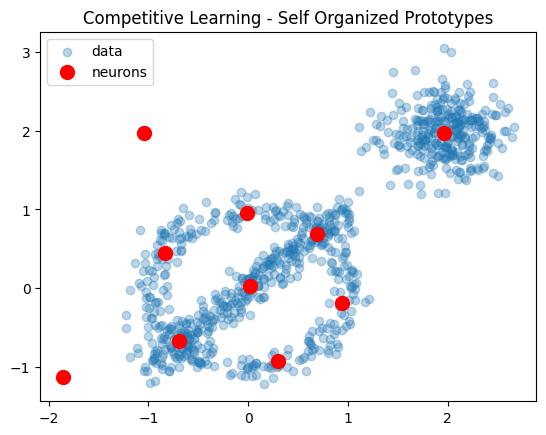

In [ ]:
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, label="data")
plt.scatter(net.weights[:, 0], net.weights[:, 1],
            color='red', s=100, label="neurons")

plt.legend()
plt.title("Competitive Learning - Self Organized Prototypes")
plt.show()